Zadanie 13

Best threshold for F1: 0.20 with F1 score: 0.53
Best threshold for Recall with Precision > 0.5: 0.30 with Recall: 0.47


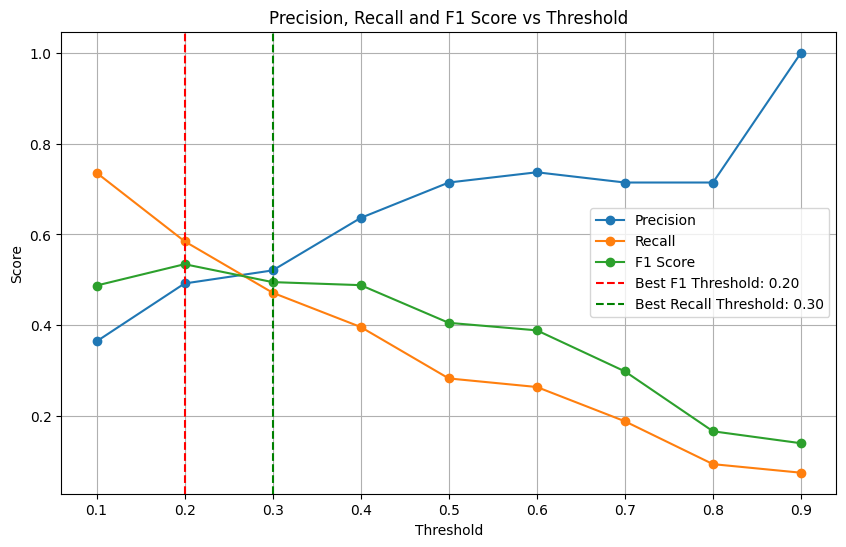

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.linear_model import LogisticRegression

X, y = make_classification(n_samples=1000, n_features=20, n_classes=2, weights=[0.95, 0.05], random_state=42)

model = LogisticRegression()
model.fit(X, y)

y_probs = model.predict_proba(X)[:, 1]

thresholds = np.arange(0.1, 1.0, 0.1)
precision_scores = []
recall_scores = []
f1_scores = []
for threshold in thresholds:
    y_pred = (y_probs >= threshold).astype(int)
    precision = precision_score(y, y_pred)
    recall = recall_score(y, y_pred)
    f1 = f1_score(y, y_pred)
    precision_scores.append(precision)
    recall_scores.append(recall)
    f1_scores.append(f1)

best_f1_index = np.argmax(f1_scores)
best_threshold = thresholds[best_f1_index]
print(f"Best threshold for F1: {best_threshold:.2f} with F1 score: {f1_scores[best_f1_index]:.2f}")

best_recall = 0
best_recall_threshold = 0
for i, (precision, recall) in enumerate(zip(precision_scores, recall_scores)):
    if precision > 0.5 and recall > best_recall:
        best_recall = recall
        best_recall_threshold = thresholds[i]
print(f"Best threshold for Recall with Precision > 0.5: {best_recall_threshold:.2f} with Recall: {best_recall:.2f}")

plt.figure(figsize=(10, 6))
plt.plot(thresholds, precision_scores, label='Precision', marker='o')
plt.plot(thresholds, recall_scores, label='Recall', marker='o')
plt.plot(thresholds, f1_scores, label='F1 Score', marker='o')
plt.axvline(x=best_threshold, color='r', linestyle='--', label=f'Best F1 Threshold: {best_threshold:.2f}')
plt.axvline(x=best_recall_threshold, color='g', linestyle='--', label=f'Best Recall Threshold: {best_recall_threshold:.2f}')
plt.title('Precision, Recall and F1 Score vs Threshold')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.legend()
plt.grid()
plt.show()

Zadanie 16

Cross-validation results:
Accuracy: 0.95 ± 0.02
Precision: 0.96 ± 0.03
Recall: 0.97 ± 0.03
F1: 0.96 ± 0.01


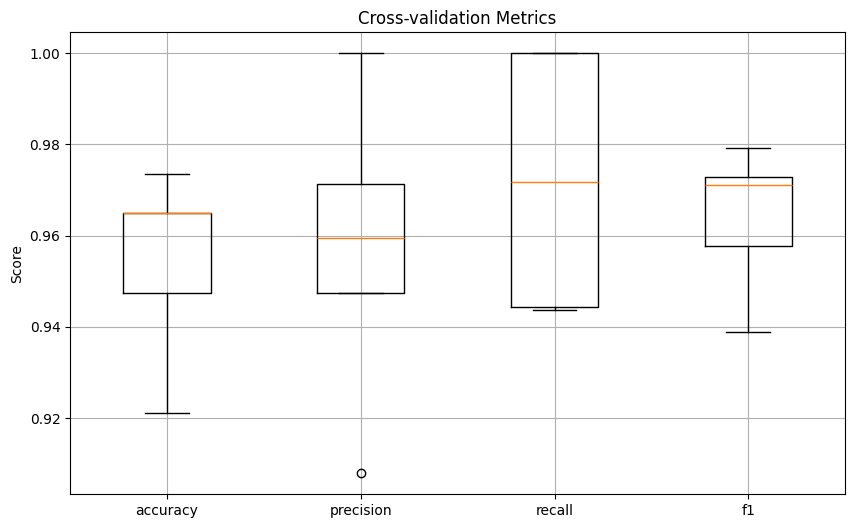

In [8]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_validate
from sklearn.metrics import make_scorer, accuracy_score, precision_score, recall_score, f1_score
data = load_breast_cancer()
X = data.data
y = data.target 
model = LogisticRegression(max_iter=10000)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = {
    'accuracy': make_scorer(accuracy_score),
    'precision': make_scorer(precision_score),
    'recall': make_scorer(recall_score),
    'f1': make_scorer(f1_score)
}
cv_results = cross_validate(model, X, y, cv=skf, scoring=scoring)
metrics = ['accuracy', 'precision', 'recall', 'f1']

print("Cross-validation results:")
for metric in metrics:
    mean_score = np.mean(cv_results[f'test_{metric}'])
    std_score = np.std(cv_results[f'test_{metric}'])
    print(f"{metric.capitalize()}: {mean_score:.2f} ± {std_score:.2f}")

plt.figure(figsize=(10, 6))
plt.boxplot([cv_results[f'test_{metric}'] for metric in metrics], tick_labels=metrics)
plt.title('Cross-validation Metrics')
plt.ylabel('Score')
plt.grid()
plt.show()  




Zadanie 18

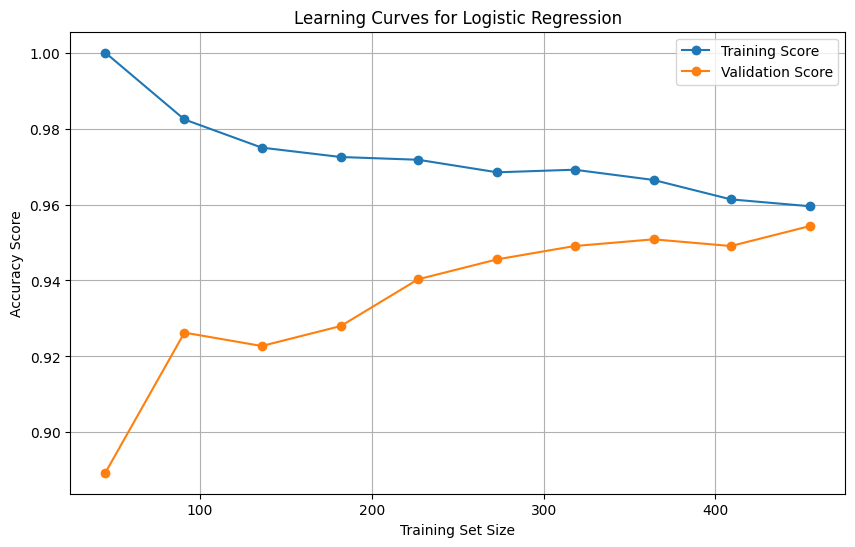

In [ ]:
from sklearn.model_selection import learning_curve
train_sizes, train_scores, validation_scores = learning_curve(
    model, X, y, cv=skf, scoring='accuracy', n_jobs=-1, train_sizes=np.linspace(0.1, 1.0, 10), random_state=42
)   
train_scores_mean = np.mean(train_scores, axis=1)
validation_scores_mean = np.mean(validation_scores, axis=1)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_scores_mean, label='Training Score', marker='o')
plt.plot(train_sizes, validation_scores_mean, label='Validation Score', marker='o')
plt.title('Learning Curves for Logistic Regression')
plt.xlabel('Training Set Size')
plt.ylabel('Accuracy Score')
plt.legend()
plt.grid()
plt.show()  


For smaller training sizes - overfitting (training >> validation), for bigger training sizes (> 400) no overfitting